# TD2 : Préparation de données - Nettoyage de données sales
## Dataset : Palmer Penguins (version dégradée)

**Contexte :** Les données réelles sont rarement propres. Ce dataset contient les problèmes les plus courants rencontrés en pratique. L'objectif est de les **détecter puis les corriger** méthodiquement.

**Datamap (dictionnaire des données) :**

| Colonne | Type | Description |
|---|---|---|
| `species` | catégorielle | Espèce du manchot : `Adelie`, `Chinstrap` ou `Gentoo` |
| `island` | catégorielle | Île de l'archipel Palmer où l'individu a été observé |
| `bill_length_mm` | numérique (mm) | Longueur du bec |
| `bill_depth_mm` | numérique (mm) | Profondeur (hauteur) du bec |
| `flipper_length_mm` | numérique (mm) | Longueur des nageoires |
| `body_mass_g` | numérique (g) | Masse corporelle |
| `sex` | catégorielle | Sexe de l'individu, encodé de façon incohérente (M/Male/MALE...) |
| `data_source` | *problématique* | Constante sur toutes les lignes : à supprimer, n'apporte aucune information |
| `year_recorded` | *problématique* | Année de collecte, avec une erreur de format (nombre stocké en texte) |

**Problèmes à traiter :**
1. **Doublons** : lignes entièrement dupliquées
2. **Variables inutiles** : colonnes constantes ou identifiants
3. **Valeurs manquantes** : encodées de plusieurs façons (NaN, '', '?', 'unknown')
4. **Incohérences catégorielles** : casse, espaces, modalités équivalentes (M/Male/MALE)
5. **Valeurs aberrantes** : impossibles physiquement (masse négative, etc.)
6. **Erreurs de type** : nombres stockés en texte

**Démarche :** détecter → corriger → valider, puis refaire l'analyse descriptive du TD1 sur les données propres.

---
## 0. Imports & chargement

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv('penguins_dirty.csv')
print(f"Dimensions initiales : {df.shape[0]} lignes × {df.shape[1]} colonnes")
df.head(10)

Dimensions initiales : 351 lignes × 9 colonnes


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,data_source,year_recorded
0,Gentoo,Biscoe,42.9,13.1,215.0,5000.0,Female,palmer_station,2009
1,Adelie,Dream,37.3,17.8,191.0,3350.0,Female,palmer_station,2009
2,Chinstrap,Dream,50.8,19.0,210.0,4100.0,Male,palmer_station,2007
3,Adelie,Biscoe,36.4,17.1,184.0,2850.0,Female,palmer_station,2009
4,Adelie,Torgersen,45.8,18.9,197.0,4150.0,Male,palmer_station,2007
5,Gentoo,biscoe,45.1,14.5,207.0,5050.0,Female,palmer_station,2008
6,Adelie,Torgersen,42.5,20.7,197.0,4500.0,Male,palmer_station,2009
7,Adelie,Biscoe,40.6,18.8,193.0,3800.0,Male,palmer_station,2008
8,Chinstrap,Dream,51.5,18.7,187.0,3250.0,Male,palmer_station,2009
9,Gentoo,Biscoe,46.4,15.0,216.0,4700.0,Female,palmer_station,2007


---
## 1. Diagnostic initial

Avant de corriger, on établit un **état des lieux complet** des problèmes.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            351 non-null    str    
 1   island             351 non-null    str    
 2   bill_length_mm     326 non-null    float64
 3   bill_depth_mm      351 non-null    float64
 4   flipper_length_mm  351 non-null    float64
 5   body_mass_g        326 non-null    float64
 6   sex                348 non-null    str    
 7   data_source        351 non-null    str    
 8   year_recorded      351 non-null    str    
dtypes: float64(4), str(5)
memory usage: 24.8 KB


In [9]:
# Aperçu des modalités de chaque colonne texte → révèle les incohérences
for col in df.select_dtypes(include='object').columns:
    vals = df[col].unique()
    print(f"=== {col} ({len(vals)} valeurs uniques) ===")
    print(sorted([repr(v) for v in vals]))
    print()

=== species (9 valeurs uniques) ===
["' Adelie '", "' Chinstrap '", "' Gentoo '", "'ADELIE'", "'Adelie'", "'CHINSTRAP'", "'Chinstrap'", "'GENTOO'", "'Gentoo'"]

=== island (6 valeurs uniques) ===
["'Biscoe'", "'Dream'", "'Torgersen'", "'biscoe'", "'dream'", "'torgersen'"]

=== sex (9 valeurs uniques) ===
["'?'", "'F'", "'Female'", "'M'", "'MALE'", "'Male'", "'female'", "'unknown'", 'nan']

=== data_source (1 valeurs uniques) ===
["'palmer_station'"]

=== year_recorded (4 valeurs uniques) ===
["'2,008'", "'2007'", "'2008'", "'2009'"]



In [10]:
# Statistiques numériques → révèle les valeurs aberrantes (min/max impossibles)
df.describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,326.00,351.00,351.00,326.00
mean,46.91,17.20,213.31,4718.52
std,53.25,1.96,257.02,7122.13
min,-5.00,13.10,1.00,0.00
25%,39.52,15.70,190.00,3550.00
50%,45.10,17.40,197.00,4000.00
75%,48.70,18.70,212.50,4750.00
max,999.00,21.50,5000.00,99999.00


> **Observations du diagnostic :**
> - `sex` a des valeurs incohérentes : `M`, `F`, `Male`, `MALE`, `female`, `unknown`, `?`, `''`
> - `species` et `island` ont des problèmes de casse et d'espaces
> - `body_mass_g` a un max à 99999 et un min à 0 (impossibles)
> - `bill_length_mm` a des valeurs négatives
> - `data_source` semble constante, `year_recorded` est en texte

On corrige maintenant **problème par problème**.

---
## 2. Suppression des doublons

In [11]:
n_dup = df.duplicated().sum()
print(f"Doublons complets détectés : {n_dup}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Après suppression : {df.shape[0]} lignes")

Doublons complets détectés : 9
Après suppression : 342 lignes


---
## 3. Suppression des variables inutiles, variables non pertinentes


On retire les colonnes sans valeur informative pour l'analyse :
- Colonnes **constantes** (variance nulle)
- **Identifiants** uniques (pas des variables d'intérêt)

In [33]:
# Détection des colonnes constantes
constant_cols = [c for c in df.columns if df[c].nunique() <= 1]
print(f"Colonnes constantes : {constant_cols}")

# Suppression de data_source (constante)
df = df.drop(columns=constant_cols)
print(f"Colonnes restantes : {list(df.columns)}")

Colonnes constantes : []
Colonnes restantes : ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year_recorded']


---
## 4. Correction des erreurs de type

`year_recorded` est en texte avec des valeurs malformées (`'2,008'`). On le convertit en numérique.

In [13]:
print("Avant :", df['year_recorded'].unique())

# Nettoyer : retirer les virgules puis convertir
df['year_recorded'] = df['year_recorded'].astype(str).str.replace(',', '', regex=False)
df['year_recorded'] = pd.to_numeric(df['year_recorded'], errors='coerce').astype('Int64')

print("Après :", sorted(df['year_recorded'].dropna().unique()))

Avant : <StringArray>
['2009', '2007', '2008', '2,008']
Length: 4, dtype: str
Après : [np.int64(2007), np.int64(2008), np.int64(2009)]


---
## 5. Recodage et harmonisation des variables catégorielles

On uniformise la casse, on retire les espaces, et on regroupe les modalités équivalentes.

In [14]:
# Étape 1 : nettoyer espaces et casse pour species et island
for col in ['species', 'island']:
    df[col] = df[col].astype(str).str.strip().str.title()  # strip espaces + Title Case

print("species :", sorted(df['species'].unique()))
print("island  :", sorted(df['island'].unique()))

species : ['Adelie', 'Chinstrap', 'Gentoo']
island  : ['Biscoe', 'Dream', 'Torgersen']


In [15]:
# Étape 2 : harmoniser sex - regrouper toutes les variantes
print("Avant :", sorted([repr(v) for v in df['sex'].unique()]))

# Dictionnaire de recodage
sex_mapping = {
    'male': 'Male', 'm': 'Male', 'MALE': 'Male', 'Male': 'Male',
    'female': 'Female', 'f': 'Female', 'FEMALE': 'Female', 'Female': 'Female',
}

# Normaliser d'abord (strip + casse), puis mapper
df['sex'] = df['sex'].astype(str).str.strip()
# Les valeurs manquantes textuelles deviennent NaN
df['sex'] = df['sex'].replace(['unknown', '?', '', 'nan', 'None'], np.nan)
# Appliquer le mapping (insensible à la casse via .str.lower())
df['sex'] = df['sex'].apply(lambda x: sex_mapping.get(str(x).lower(), sex_mapping.get(x, x)) if pd.notna(x) else x)

print("Après :", sorted([repr(v) for v in df['sex'].dropna().unique()]))
print(f"NA dans sex : {df['sex'].isna().sum()}")

Avant : ["'?'", "'F'", "'Female'", "'M'", "'MALE'", "'Male'", "'female'", "'unknown'", 'nan']
Après : ["'Female'", "'Male'"]
NA dans sex : 9


---
## 6. Détection et traitement des valeurs aberrantes

Deux approches complémentaires :
- **Règles métier** : valeurs physiquement impossibles (masse ≤ 0, longueur négative)
- **Méthode statistique (IQR)** : valeurs au-delà de Q1-1.5×IQR ou Q3+1.5×IQR

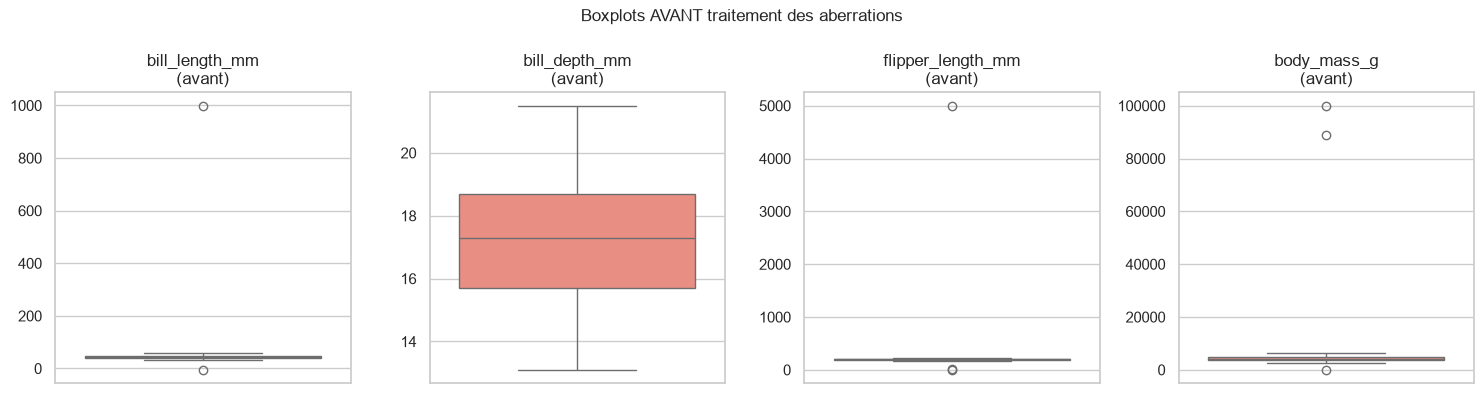

In [16]:
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Boxplots AVANT traitement → les aberrations écrasent l'échelle
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(f'{col}\n(avant)')
    ax.set_ylabel('')
plt.suptitle('Boxplots AVANT traitement des aberrations', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# Étape 1 : règles métier - valeurs impossibles → NaN
# (on les transforme en NaN pour les imputer ensuite, plutôt que de supprimer la ligne)
impossible_rules = {
    'body_mass_g':       lambda s: (s <= 100) | (s > 7000),     # manchot : 2.5-6.5 kg
    'bill_length_mm':    lambda s: (s <= 0) | (s > 100),        # bec : ~30-60 mm
    'bill_depth_mm':     lambda s: (s <= 0) | (s > 50),
    'flipper_length_mm': lambda s: (s < 100) | (s > 300),       # nageoire : ~170-230 mm
}

for col, rule in impossible_rules.items():
    mask = rule(df[col])
    n = mask.sum()
    if n > 0:
        print(f"{col} : {n} valeurs aberrantes → NaN ({df.loc[mask, col].tolist()})")
        df.loc[mask, col] = np.nan

body_mass_g : 3 valeurs aberrantes → NaN ([0.0, 99999.0, 88888.0])
bill_length_mm : 2 valeurs aberrantes → NaN ([999.0, -5.0])
flipper_length_mm : 3 valeurs aberrantes → NaN ([10.0, 5000.0, 1.0])


In [18]:
# Étape 2 : méthode IQR pour détecter d'éventuels outliers restants
def detect_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return (series < lower) | (series > upper), lower, upper

print("Outliers restants selon la règle IQR (1.5×) :")
for col in num_cols:
    mask, low, up = detect_outliers_iqr(df[col])
    print(f"  {col:20s} : {mask.sum():2d} outliers (bornes : {low:.1f} - {up:.1f})")
# Note : on garde les outliers IQR "légers" car ils peuvent être des valeurs réelles
# (ex : un manchot un peu plus grand). Seules les impossibilités physiques sont retirées.

Outliers restants selon la règle IQR (1.5×) :
  bill_length_mm       :  0 outliers (bornes : 25.9 - 62.3)
  bill_depth_mm        :  0 outliers (bornes : 11.2 - 23.2)
  flipper_length_mm    :  0 outliers (bornes : 155.5 - 247.5)
  body_mass_g          :  0 outliers (bornes : 1750.0 - 6550.0)


---
## 7. Imputation des valeurs manquantes

Après nettoyage, on a des NaN (d'origine + aberrations converties). Stratégie :
- **Numériques** : imputation par la **médiane du groupe** (par espèce) - plus précis qu'une médiane globale
- **Catégorielles** : imputation par le **mode** (valeur la plus fréquente)

In [19]:
# État des NA avant imputation
na_before = df.isnull().sum()
na_prop_before = df.isnull().mean()
print("Valeurs manquantes avant imputation :")
print(na_before[na_before > 0])
print("\nProportion de valeurs manquantes avant imputation :")
print(na_prop_before[na_prop_before > 0])

Valeurs manquantes avant imputation :
bill_length_mm       27
flipper_length_mm     3
body_mass_g          28
sex                   9
dtype: int64

Proportion de valeurs manquantes avant imputation :
bill_length_mm       0.078947
flipper_length_mm    0.008772
body_mass_g          0.081871
sex                  0.026316
dtype: float64


In [20]:
# Imputation numérique par médiane de l'espèce (transform garde l'alignement des index)
for col in num_cols:
    df[col] = df.groupby('species')[col].transform(lambda s: s.fillna(s.median()))

# Imputation catégorielle par le mode
for col in ['sex']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"{col} imputé par le mode : '{mode_val}'")

# year_recorded : mode
if df['year_recorded'].isna().any():
    df['year_recorded'] = df['year_recorded'].fillna(df['year_recorded'].mode()[0])

print(f"\nValeurs manquantes après imputation : {df.isnull().sum().sum()}")

sex imputé par le mode : 'Female'

Valeurs manquantes après imputation : 0


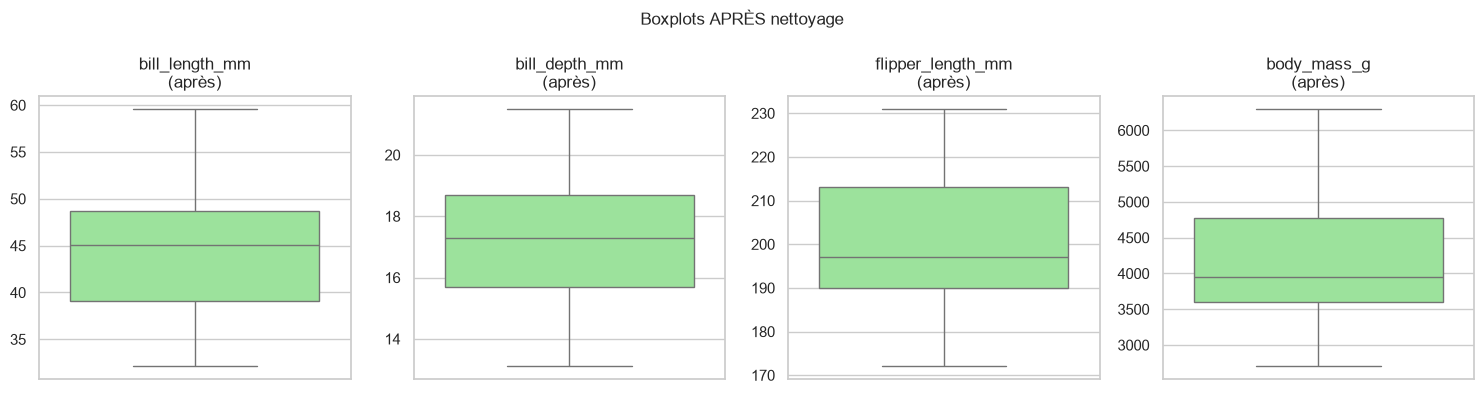

In [21]:
# Boxplots APRÈS traitement → échelle redevenue lisible
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(f'{col}\n(après)')
    ax.set_ylabel('')
plt.suptitle('Boxplots APRÈS nettoyage', fontsize=12)
plt.tight_layout()
plt.show()

---
## 8. Sélection et filtrage

On peut maintenant **sélectionner les variables d'intérêt** et **filtrer** selon des critères métier.

In [22]:
# Sélection des variables pertinentes pour l'analyse
# (on retire year_recorded qui n'apporte rien à l'analyse morphologique)
variables_interet = ['species', 'island', 'sex'] + num_cols
df_final = df[variables_interet].copy()

# Après suppression de colonnes, de nouveaux doublons peuvent apparaître
# (lignes qui ne différaient que par une colonne supprimée). On re-vérifie.
n_new_dup = df_final.duplicated().sum()
if n_new_dup > 0:
    print(f'Nouveaux doublons après sélection : {n_new_dup} → supprimés')
    df_final = df_final.drop_duplicates().reset_index(drop=True)

print(f"Variables sélectionnées : {list(df_final.columns)}")

# Exemple de filtrage : ne garder qu'une espèce, ou un sous-groupe
exemple_filtre = df_final[df_final['body_mass_g'] > 4000]
print(f"\nExemple de filtre (masse > 4000g) : {len(exemple_filtre)} manchots sur {len(df_final)}")

Nouveaux doublons après sélection : 2 → supprimés
Variables sélectionnées : ['species', 'island', 'sex', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

Exemple de filtre (masse > 4000g) : 164 manchots sur 340


---
## 9. Validation : le dataset est-il propre ?

In [23]:
print("=== RAPPORT DE NETTOYAGE ===\n")
print(f"Dimensions finales    : {df_final.shape[0]} lignes × {df_final.shape[1]} colonnes")
print(f"Doublons              : {df_final.duplicated().sum()}")
print(f"Valeurs manquantes    : {df_final.isnull().sum().sum()}")
print(f"\nModalités catégorielles harmonisées :")
for col in ['species', 'island', 'sex']:
    print(f"  {col:10s} : {sorted(df_final[col].unique())}")
print(f"\nPlages numériques (réalistes) :")
for col in num_cols:
    print(f"  {col:20s} : {df_final[col].min():.1f} : {df_final[col].max():.1f}")

=== RAPPORT DE NETTOYAGE ===

Dimensions finales    : 340 lignes × 7 colonnes
Doublons              : 0
Valeurs manquantes    : 0

Modalités catégorielles harmonisées :
  species    : ['Adelie', 'Chinstrap', 'Gentoo']
  island     : ['Biscoe', 'Dream', 'Torgersen']
  sex        : ['Female', 'Male']

Plages numériques (réalistes) :
  bill_length_mm       : 32.1 : 59.6
  bill_depth_mm        : 13.1 : 21.5
  flipper_length_mm    : 172.0 : 231.0
  body_mass_g          : 2700.0 : 6300.0


---
## 10. Analyse descriptive sur données propres

Le nettoyage terminé, on peut refaire l'analyse du TD1 (statistiques, graphiques, corrélations).

### 10.1 Statistiques descriptives

In [24]:
df_final[num_cols].describe().round(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,340.00,340.00,340.00,340.00
mean,44.04,17.18,200.83,4183.82
std,5.44,1.96,13.89,791.75
min,32.10,13.10,172.00,2700.00
25%,39.08,15.68,190.00,3600.00
50%,44.95,17.30,197.00,3962.50
75%,48.70,18.70,213.00,4781.25
max,59.60,21.50,231.00,6300.00


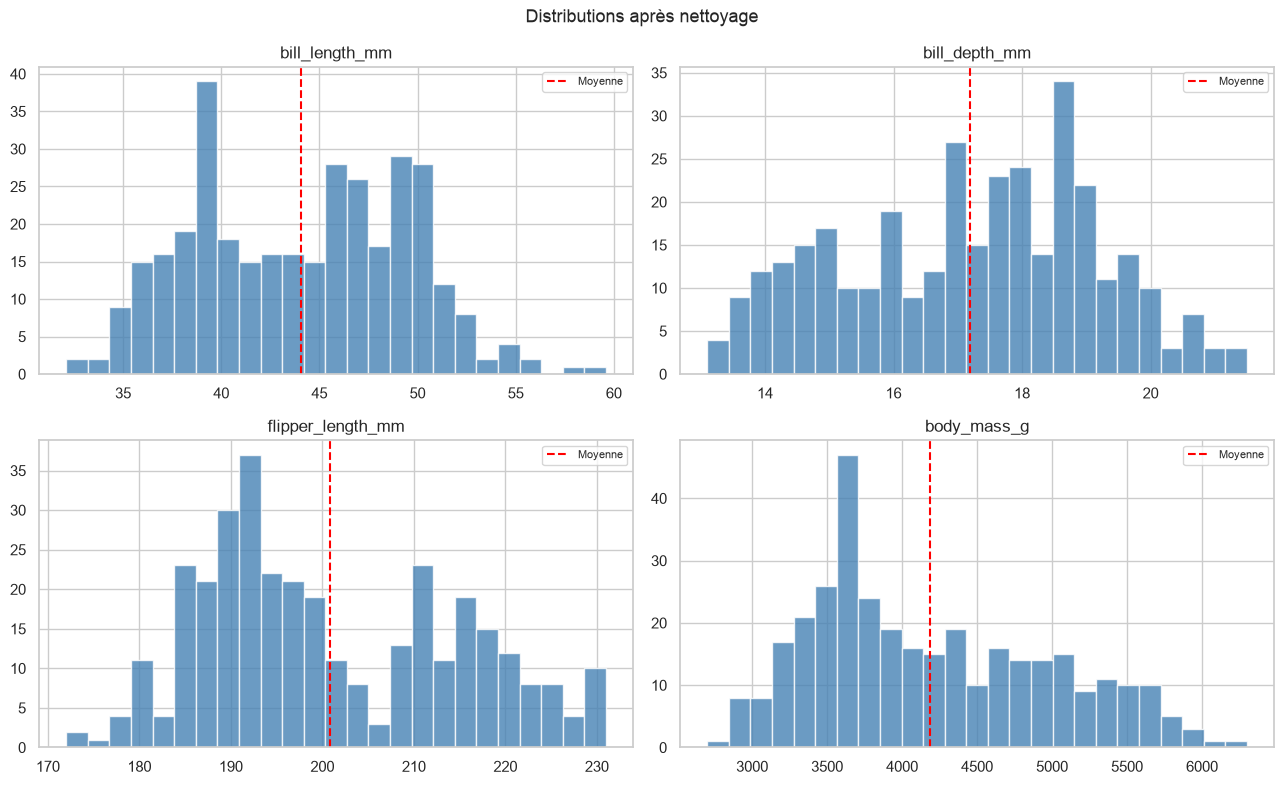

In [25]:
# Histogrammes
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    ax.hist(df_final[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(df_final[col].mean(), color='red', linestyle='--', label=f'Moyenne')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Distributions après nettoyage', fontsize=13)
plt.tight_layout()
plt.show()

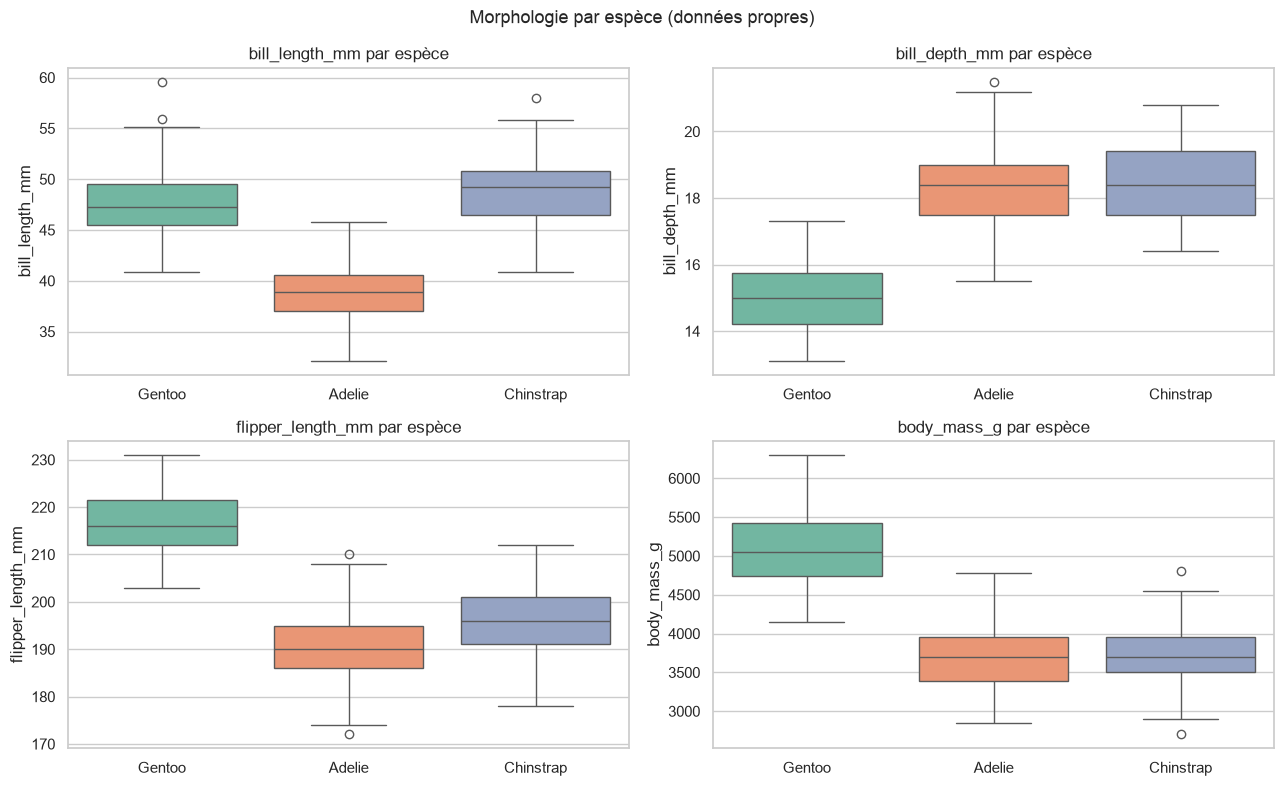

In [26]:
# Boxplots par espèce
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df_final, x='species', y=col, ax=ax, hue='species', legend=False)
    ax.set_title(f'{col} par espèce')
    ax.set_xlabel('')
plt.suptitle('Morphologie par espèce (données propres)', fontsize=13)
plt.tight_layout()
plt.show()

### 10.2 Corrélations numériques (Pearson)

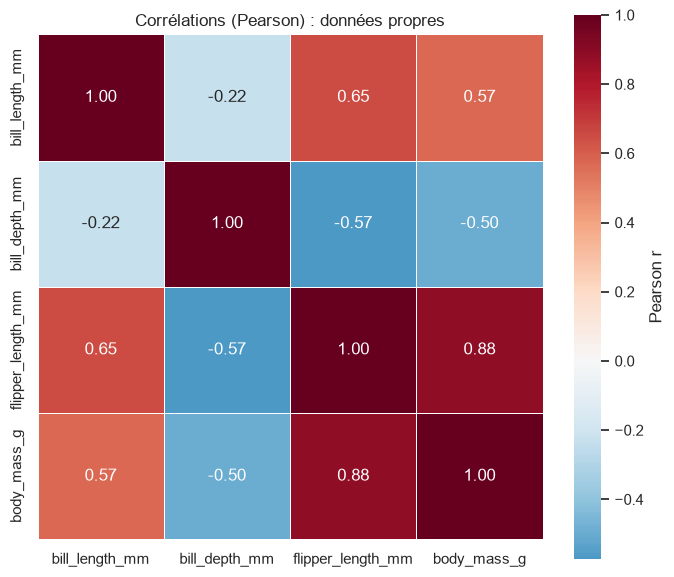

In [30]:
corr = df_final[num_cols].corr()
plt.figure(figsize=(7, 6))
# mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, #mask=mask,
            linewidths=0.5, square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Corrélations (Pearson) : données propres')
plt.tight_layout()
plt.show()

### 10.3 V de Cramér (catégorielles)

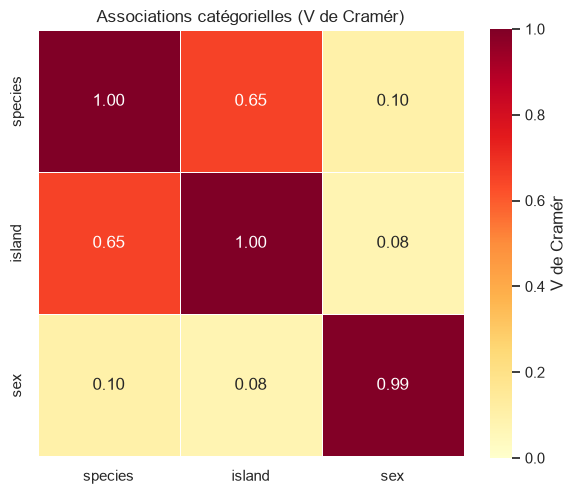

In [28]:
def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cat_cols = ['species', 'island', 'sex']
cramer_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramer_matrix.loc[c1, c2] = cramers_v(df_final[c1], df_final[c2])

plt.figure(figsize=(6, 5))
sns.heatmap(cramer_matrix.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, linewidths=0.5, square=True, cbar_kws={'label': 'V de Cramér'})
plt.title('Associations catégorielles (V de Cramér)')
plt.tight_layout()
plt.show()

In [29]:
# Sauvegarde du dataset propre pour réutilisation
df_final.to_csv('penguins_cleaned.csv', index=False)
print(f"Dataset propre sauvegardé : penguins_cleaned.csv ({df_final.shape[0]} lignes)")

Dataset propre sauvegardé : penguins_cleaned.csv (340 lignes)


---
## 11. Synthèse

**Pipeline de nettoyage appliqué (ordre important) :**
1. **Diagnostic** : inspecter types, modalités, statistiques pour repérer les problèmes
2. **Doublons** : `drop_duplicates()`
3. **Variables inutiles** : colonnes constantes et identifiants
4. **Types** : conversion des nombres stockés en texte
5. **Harmonisation catégorielle** : casse, espaces, regroupement de modalités
6. **Aberrations** : règles métier (impossibilités) + détection IQR
7. **Imputation** : médiane par groupe (numérique), mode (catégoriel)
8. **Sélection / filtrage** : variables d'intérêt et sous-populations (+ re-dédoublonnage : supprimer des colonnes peut créer de nouveaux doublons)
9. **Validation** : vérifier qu'il ne reste ni doublon, ni NA, ni incohérence

**Bonnes pratiques :**
- Toujours **diagnostiquer avant de corriger** : on ne nettoie bien que ce qu'on a compris
- **Imputer plutôt que supprimer** quand c'est possible (préserve la taille de l'échantillon)
- Distinguer **aberration** (à corriger) et **valeur extrême réelle** (à garder)
- **Documenter** chaque transformation (traçabilité, reproductibilité)
- Garder les données brutes intactes : travailler sur une copie

**Résultat :** un dataset propre, prêt pour l'analyse descriptive (TD1) puis la modélisation.